# iADP / nonlinear F-16: Actuator command-gain loss

This updated example requests **500 seconds** with the current unregularized iADP critic and continuous model/critic adaptation. It uses the native nonlinear longitudinal F-16, including the servo and physical envelope checks. The fault schedule is supplied only to the plant.

The former softened-critic tuning scores do not apply to this implementation. The supplied integral/rate features are a reduced representation of the aircraft; this example is a diagnostic, not the paper's full-state flight-test reproduction. The earlier scalar 500-second run left its demonstration envelope at step 4461 (89.24 s).

Each run records actual completion time and a failure reason. Plots stop at the last valid sample; failed runs are never reported as successful 500-second tracking. Initial settings need fresh healthy-plant tuning. The current example compares healthy/faulty continuously adapting controllers, without freezing at the fault.

In [1]:
%matplotlib inline
from pathlib import Path
from functools import partial
import sys, json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
repo = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tensoraerospace").is_dir())
sys.path.insert(0, str(repo))
from example.reinforcement_learning.incremental_adp import example_iadp_tuned_f16 as tuned
from example.reinforcement_learning.incremental_adp import example_iadp_aero_effectiveness_f16 as aero
plt.rcParams.update({"figure.dpi":120,"axes.grid":True,"grid.alpha":.2,"font.size":11})
kind = 'command'
cfg = tuned.baseline.Experiment(duration=500.0, fault_time=20.0, loss=0.15, phase=0.0)
tuning = tuned.INTEGRAL_TUNING


In [2]:
traces, results = {}, {}
for condition, has_fault in [("Healthy", False), ("Fault", True)]:
    rows = []
    extra = {}
    if kind == "aerodynamic":
        extra["environment_factory"] = partial(
            aero.make_environment,
            aero_fault=aero.AeroFault(time_s=cfg.fault_time, effectiveness=0.7),
        )
    failure = None
    try:
        trace, diagnostics = tuned.rollout(
            cfg, tuning, fault=has_fault, telemetry=rows,
            frozen_after_event=False, **extra,
        )
    except (RuntimeError, ValueError, FloatingPointError, np.linalg.LinAlgError) as exc:
        failure = str(exc)
    data = np.asarray(rows)
    traces[condition] = data
    completed = float(data[-1,0]) if len(data) else 0.0
    after = data[:,0] >= cfg.fault_time if len(data) else np.array([], dtype=bool)
    results[condition] = {
        "requested_duration_s":cfg.duration,
        "completed_duration_s":completed,
        "failure":failure,
        "post_event_rmse_deg_s":float(np.sqrt(np.mean((data[after,2]-data[after,1])**2))) if after.any() else None,
        "note":"RMSE covers completed samples only; a failed run is not a 500-second success.",
    }
output = repo / "outputs" / f"paper-iadp-f16-long-{kind}"
output.mkdir(parents=True, exist_ok=True)
(output / "summary.json").write_text(json.dumps(results, indent=2)+"\n")
for condition, data in traces.items():
    np.savetxt(output / f"{condition.lower()}-telemetry.csv", data, delimiter=",")
display(Markdown("| Scenario | Completed / requested [s] | Failure |\n|---|---:|---|\n" + "\n".join(
    f"| {label} | {r['completed_duration_s']:.2f} / {r['requested_duration_s']:.0f} | {r['failure'] or 'None'} |"
    for label,r in results.items())))
print(json.dumps(results, indent=2))


| Scenario | Completed / requested [s] | Failure |
|---|---:|---|
| Healthy | 8.36 / 500 | Left the demonstration flight envelope at 418 |
| Fault | 8.36 / 500 | Left the demonstration flight envelope at 418 |

{
  "Healthy": {
    "requested_duration_s": 500.0,
    "completed_duration_s": 8.36,
    "failure": "Left the demonstration flight envelope at 418",
    "post_event_rmse_deg_s": null,
    "note": "RMSE covers completed samples only; a failed run is not a 500-second success."
  },
  "Fault": {
    "requested_duration_s": 500.0,
    "completed_duration_s": 8.36,
    "failure": "Left the demonstration flight envelope at 418",
    "post_event_rmse_deg_s": null,
    "note": "RMSE covers completed samples only; a failed run is not a 500-second success."
  }
}


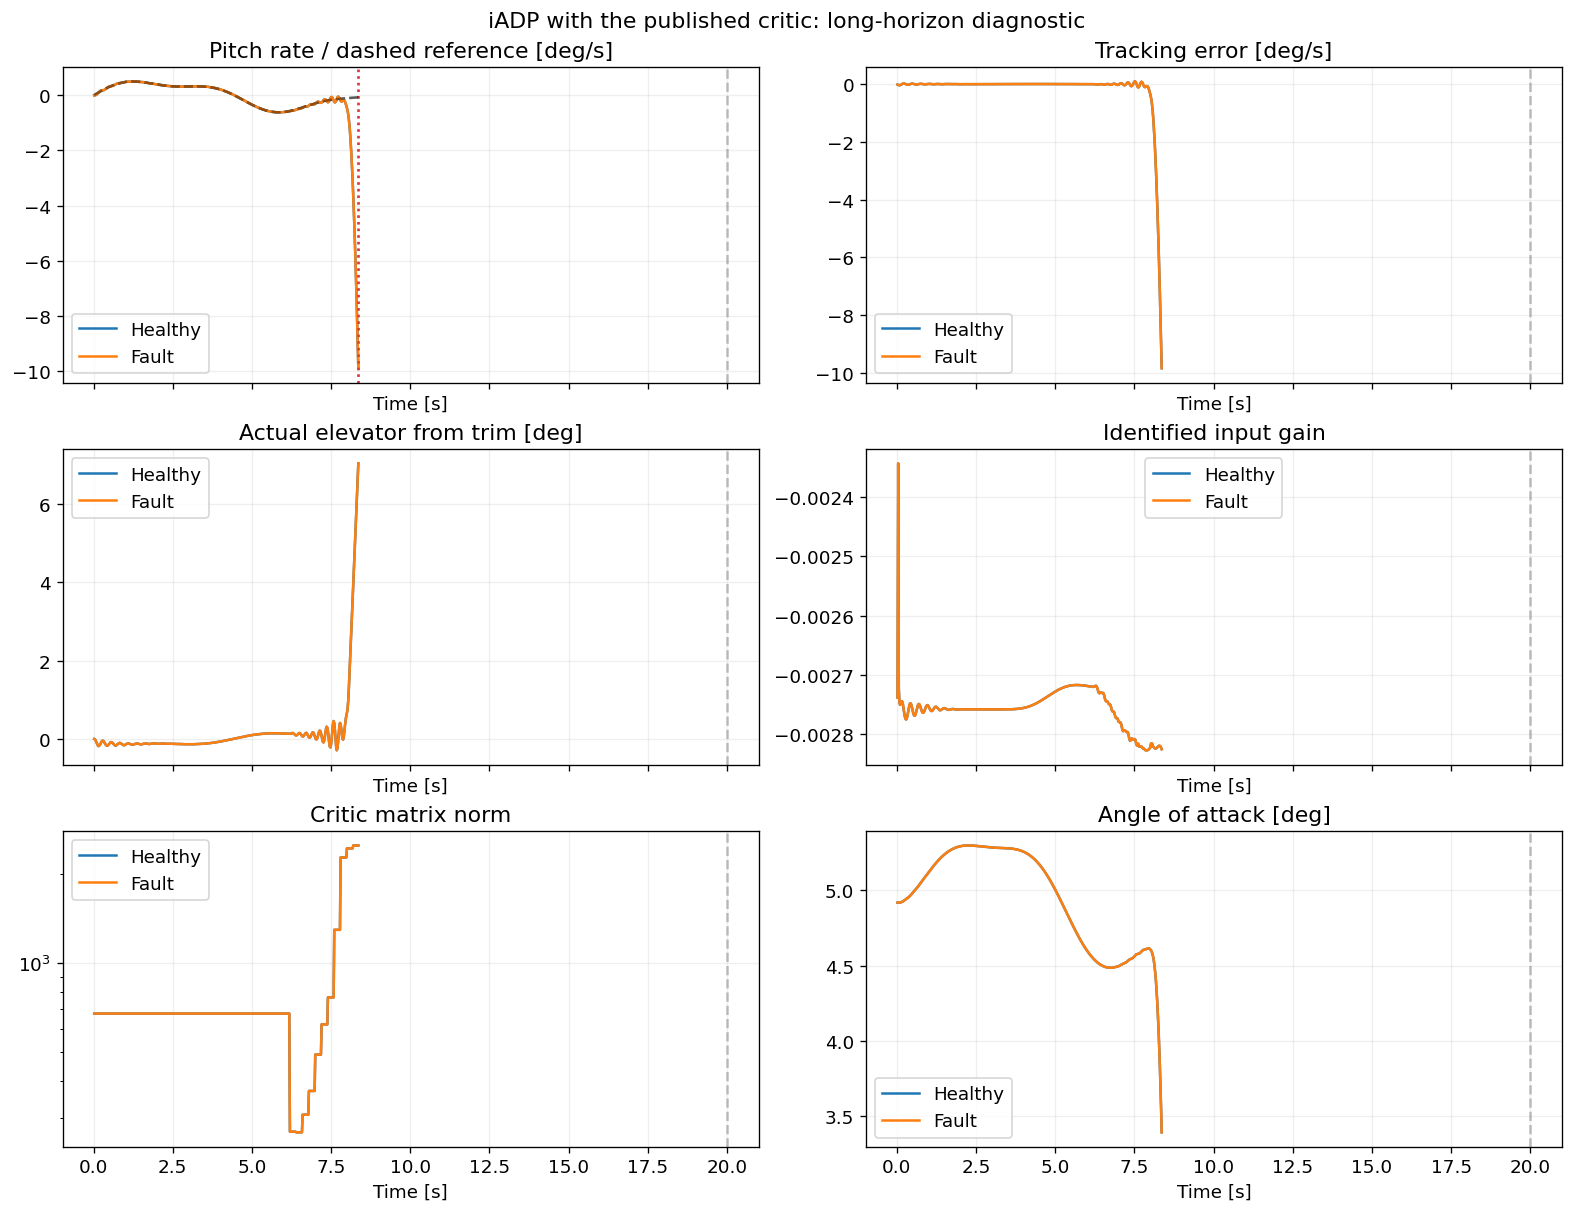

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True, constrained_layout=True)
for condition, data in traces.items():
    if not len(data):
        continue
    t = data[:,0]
    axes[0,0].plot(t, data[:,2], label=condition)
    axes[0,1].plot(t, data[:,2]-data[:,1], label=condition)
    axes[1,0].plot(t, data[:,7], label=condition)
    axes[1,1].plot(t, data[:,10], label=condition)
    axes[2,0].semilogy(t, np.maximum(data[:,11],1e-20), label=condition)
    axes[2,1].plot(t, data[:,3], label=condition)
    if results[condition]["failure"]:
        axes[0,0].axvline(t[-1], ls=":", color="tab:red", alpha=.7)
    axes[0,0].plot(t, data[:,1], "k--", alpha=.4)
for ax, title in zip(axes.flat,["Pitch rate / dashed reference [deg/s]","Tracking error [deg/s]",
                                "Actual elevator from trim [deg]","Identified input gain",
                                "Critic matrix norm","Angle of attack [deg]"]):
    ax.set_title(title)
    ax.axvline(cfg.fault_time, color="gray", ls="--", alpha=.5)
    ax.legend()
    ax.set_xlabel("Time [s]")
fig.suptitle("iADP with the published critic: long-horizon diagnostic")
fig.savefig(output / "diagnostic.png")
plt.show()
